In [1]:
import jax
from jax import flatten_util, vmap, grad 
import jax.numpy as jnp
import jax.random as jr

import matplotlib.pyplot as plt
from functools import partial
import optax
from helper_fns_general import sample_gaussian_mixture, normalize_samples, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_overdamped_SDE, solve_SDE, setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch, sample_forward_process_minusx_plus_sqrt2D_dw
from plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, get_best_params
jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Generate samples from a Gaussian mixture

In [2]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 1000

# Define mixture weights (must sum to 1)
weights = jnp.array([.5, .5])

# Define means
means = jnp.array([
    [0.5, 0.0],   # mean of first Gaussian
    [-0.5, 0.0],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.01, 0.0],    # covariance of first Gaussian
        [0.0, 0.01]],
    [[0.01, 0.0],   # covariance of second Gaussian
        [0.0, 0.01]],
])

# Generate samples
samples_0 = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)

### Plot samples and marginal distributions

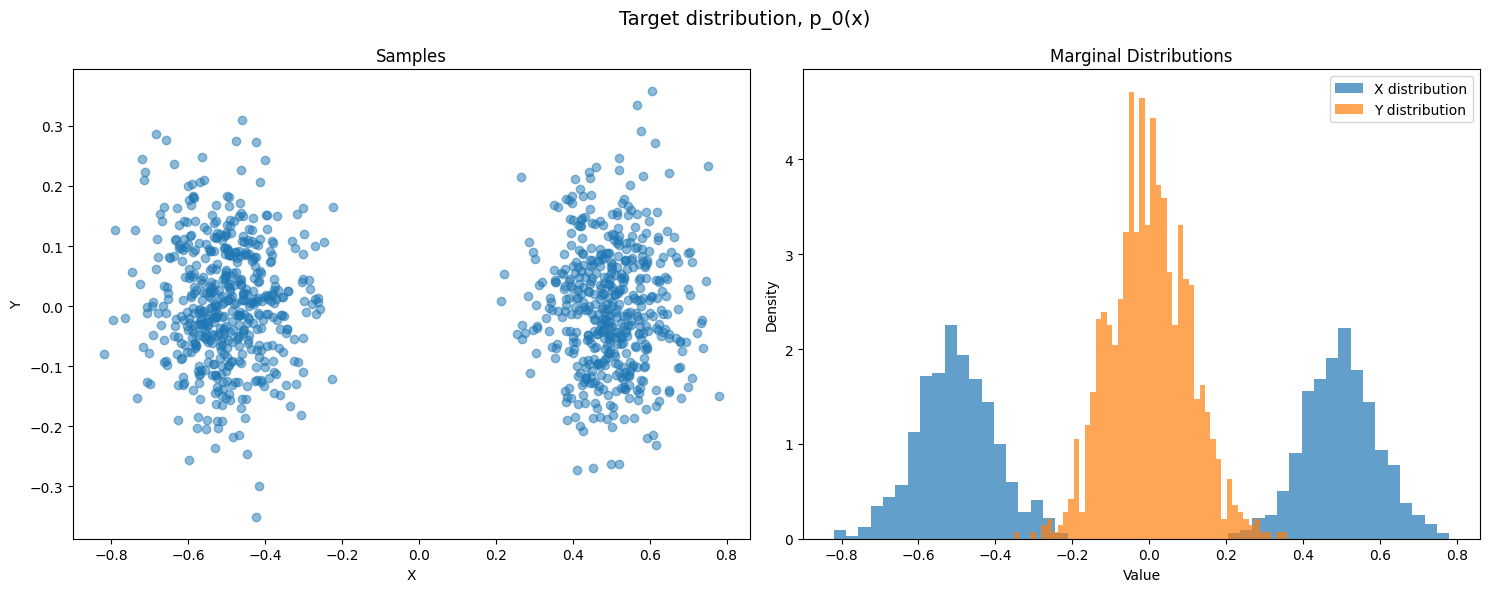

In [3]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_0[:, 0], samples_0[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_0[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_0[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')
ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()


plt.tight_layout()
plt.show()

In [4]:
key, subkey = jr.split(key)
t_forward = .2
samples_t = sample_forward_process_minusx_plus_sqrt2D_dw(t_forward, n_samples, D=1, samples0=samples_0, key=subkey)

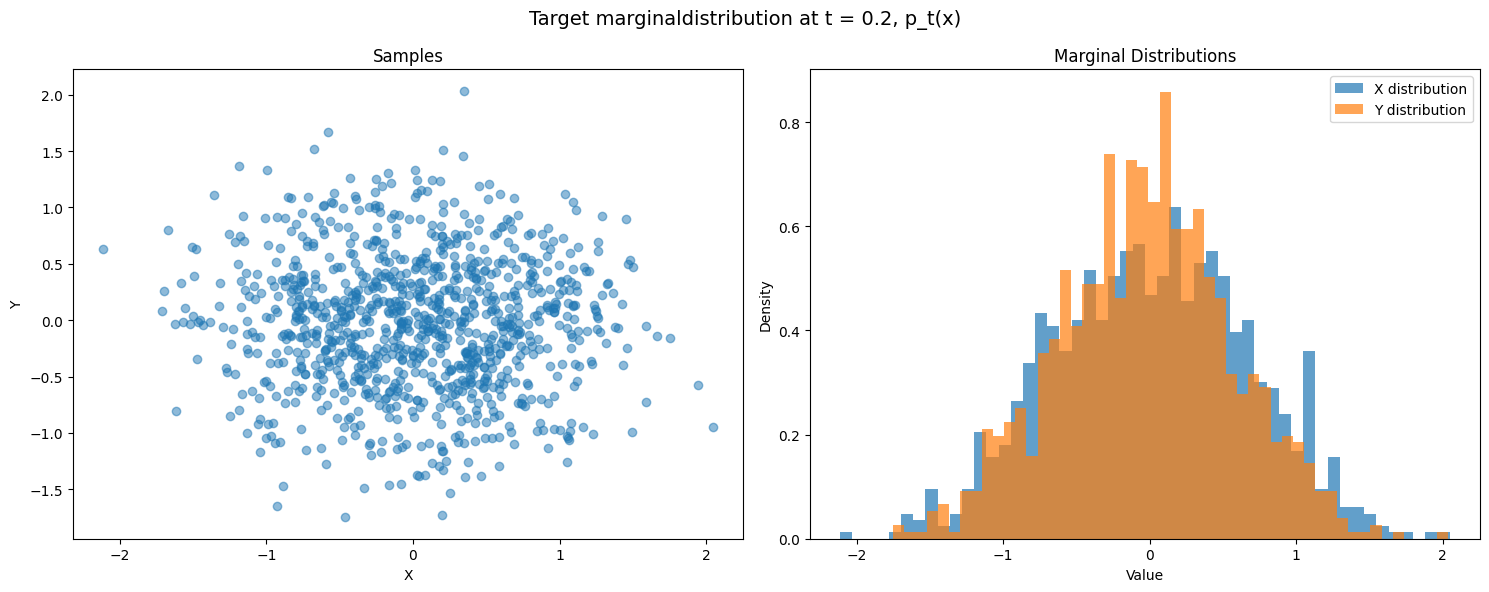

In [5]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Target marginaldistribution at t = {t_forward}, p_t(x)', fontsize=14)


# First subplot: Scatter plot of samples
ax1.scatter(samples_t[:, 0], samples_t[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_t[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_t[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')
ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Define energy function of duffing oscillator network

In [6]:
def energy_self_oscillator(x, k_lin, k_duff):
    return 1 / 2 * k_lin * x**2 + 1 / 4 * k_duff * x**4

def energy_self_network(x, k_lin, k_duff):
    return jnp.sum(vmap(energy_self_oscillator)(x, k_lin, k_duff))


def energy_coupling_pair(x, y, c_lin, c_optomech):
    return c_lin * x * (x - y) + c_lin * y * (y - x) + c_optomech * (x**2) * y

def energy_coupling_network(x, c_lin, c_optomech, connectivity):
    # get contribution to total energy from each pair of oscillators
    
    def _coupling_energy_pair(x, c_lin, c_optomech, pair):
        # get energy of one pair of oscillators
        i, j = pair
        return energy_coupling_pair(x[i], x[j], c_lin, c_optomech)

    # get energy of all pairs of oscillators
    return jnp.sum(
        vmap(_coupling_energy_pair, in_axes=(None, 0, 0, 0))(
            x, c_lin, c_optomech, connectivity
        )
    )

k_b = 1.0
T = .1
def _energy_duffing_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b=k_b, T=T):
    # returns energy of network of oscillators given input parameters
    return (
        energy_self_network(x, k_lin, k_duff) +
        energy_coupling_network(x, c_lin, c_optomech, connectivity)
    ) / (k_b * T)

### Define initial parameters

In [7]:
N_osc = 2

k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 1.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])
connectivity = jnp.array([[0, 1]])

args_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)

flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)

### Bringe energy into correct form

In [8]:
def energy_duffing_network(x, flattened_args, connectivity):
    k_lin, k_duffing, c_lin, c_optomech = unflatten(flattened_args)
    return _energy_duffing_network(x, k_lin, k_duffing, c_lin, c_optomech, connectivity)
energy_fn = lambda x, flattened_args: energy_duffing_network(x, flattened_args, connectivity)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


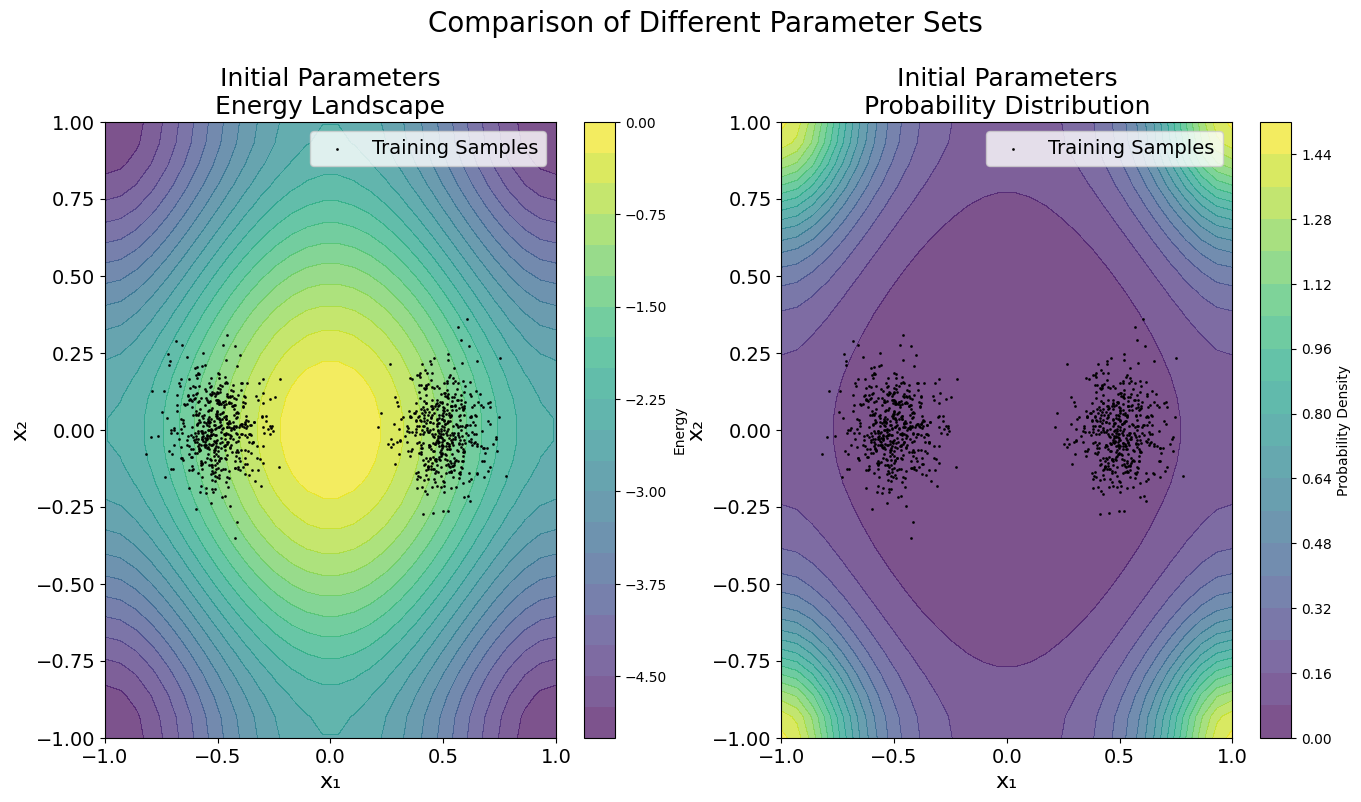

In [9]:
# Example usage:
param_list = [flattened_args_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_0,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Comparison of Different Parameter Sets" 
)

Optimizing for t = 0.000
Epoch 0
params:
[-0.99 -0.99  1.01  1.01  0.01  0.01]
Loss: 19.4421
---
Epoch 100
params:
[-0.58694801 -0.01668462  1.77072028  1.9756457   0.20502267 -0.0648074 ]
Loss: -12.2327
---
Epoch 200
params:
[-0.61322725  0.9243018   2.48300323  2.90360028  0.13830809 -0.04660441]
Loss: -24.0549
---
Epoch 300
params:
[-0.77430736  1.81793626  3.21795293  3.80994855  0.10728031 -0.03473416]
Loss: -34.7800
---
Epoch 400
params:
[-0.98233488  2.66580158  3.97620143  4.66100571  0.0968933  -0.02350293]
Loss: -42.8075
---
Epoch 500
params:
[-1.17333032  3.46105474  4.7404445   5.46593082  0.07532644 -0.06135302]
Loss: -50.2407
---
Epoch 600
params:
[-1.36064359  4.20474624  5.50260604  6.21339908  0.04636269 -0.09050742]
Loss: -57.5004
---
Epoch 700
params:
[-1.58005416  4.88508197  6.25704848  6.92956857  0.0392189   0.00860004]
Loss: -64.2973
---
Epoch 800
params:
[-1.77661003  5.52995141  7.01093092  7.59296249  0.02608399 -0.06457135]
Loss: -74.1133
---
Epoch 900
param

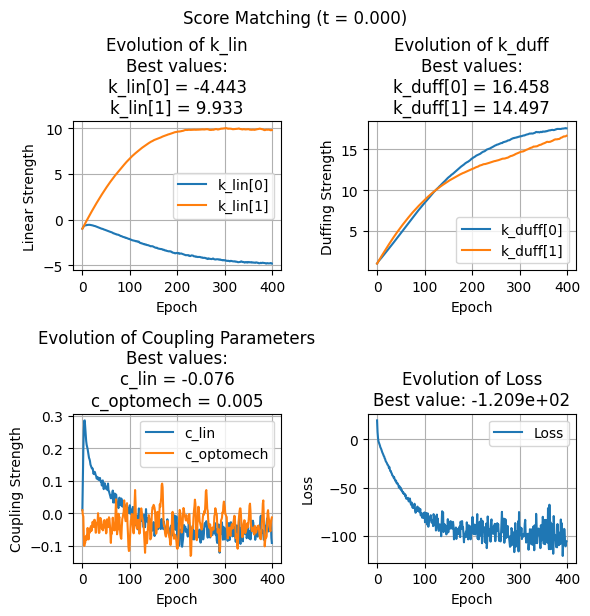

t = 0.000 probability distribution total (should be ≈ 1): 1.000000


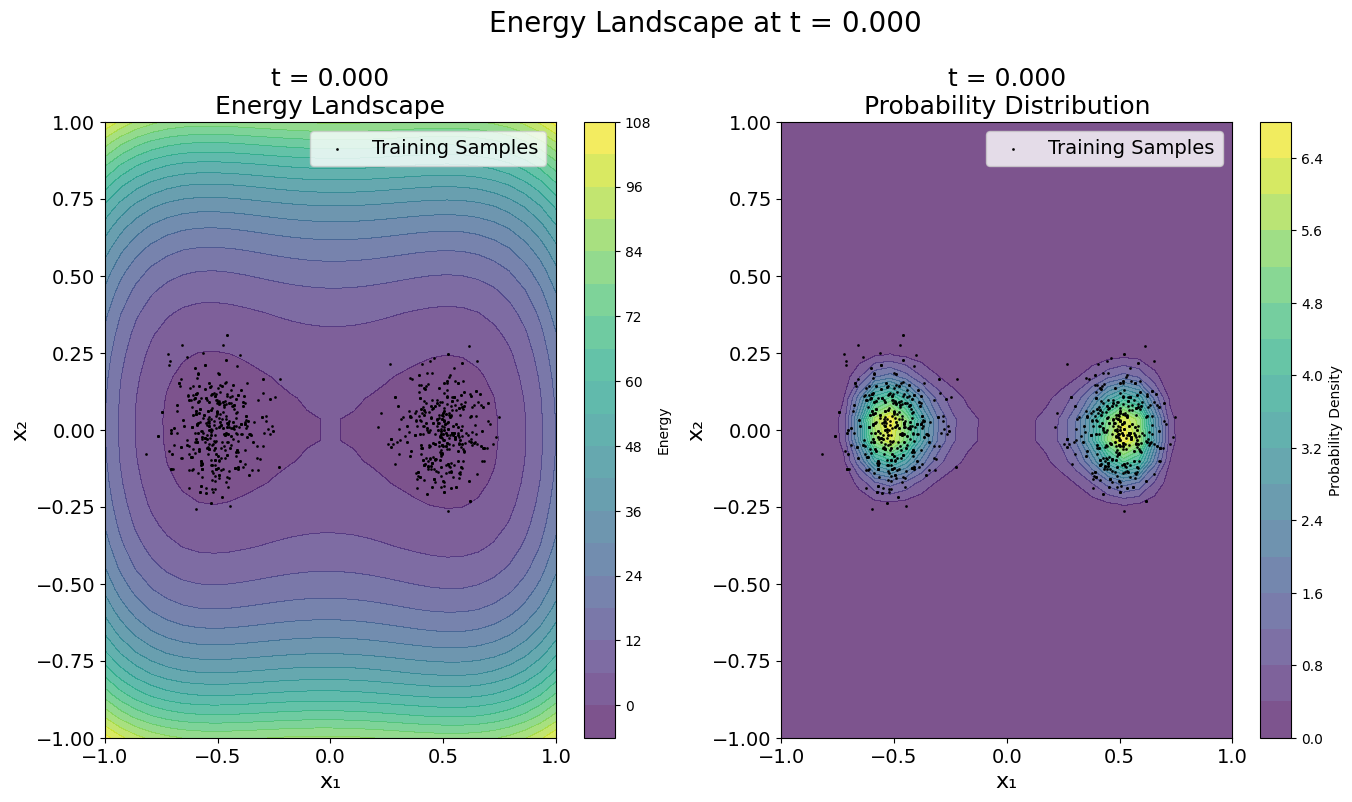

Optimizing for t = 0.002
Epoch 0
params:
[-4.43277179e+00  9.92279567e+00  1.64679035e+01  1.44865266e+01
 -6.63501477e-02  1.51282634e-02]
Loss: -76.3853
---
Epoch 100
params:
[-4.43131287  9.03077311 15.98661115 13.6527221  -0.05423981  0.02941915]
Loss: -55.4153
---
Epoch 200
params:
[-4.35354577e+00  8.36180876e+00  1.55529868e+01  1.30927243e+01
 -1.38430476e-02 -7.97357560e-02]
Loss: -74.2395
---
Epoch 300
params:
[-4.35945167  7.86678149 15.10754746 12.6424037  -0.04627256 -0.07447147]
Loss: -59.6022
---
Epoch 400
params:
[-4.18237928e+00  7.36177190e+00  1.48089685e+01  1.22004672e+01
 -2.68912578e-03 -1.98728459e-02]
Loss: -61.1444
---
Epoch 500
params:
[-4.1075032   7.0519006  14.53495684 11.82042458 -0.02257428 -0.03101614]
Loss: -71.4864
---
Epoch 600
params:
[-4.02055986e+00  6.86924905e+00  1.41855611e+01  1.16276865e+01
  3.94272049e-03 -4.17337538e-02]
Loss: -65.0369
---
Epoch 700
params:
[-3.90916037e+00  6.69072715e+00  1.40019531e+01  1.13358881e+01
  1.19182509e-02 

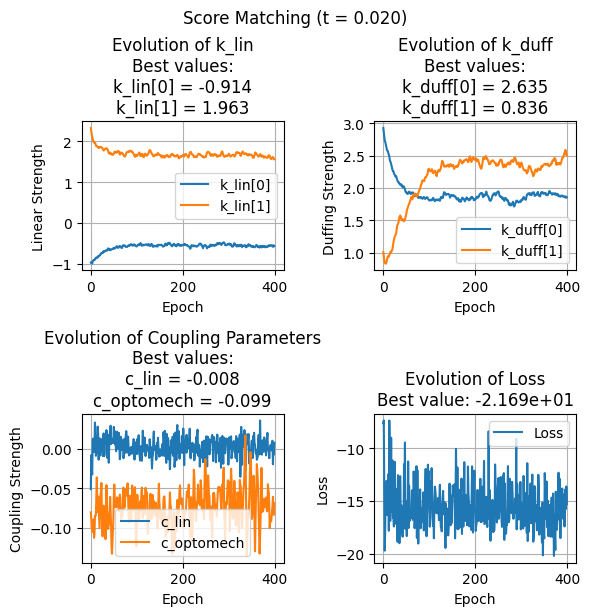

t = 0.020 probability distribution total (should be ≈ 1): 1.000000


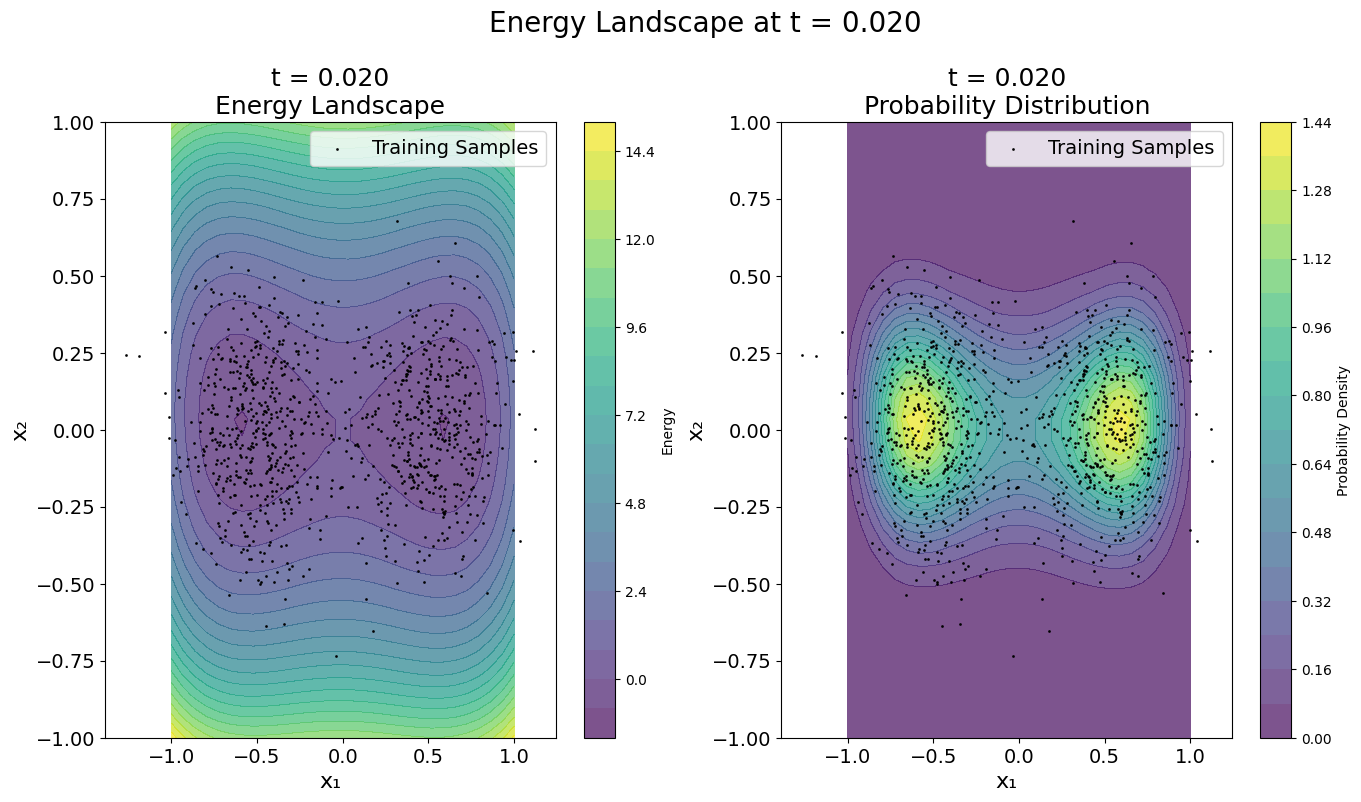

Optimizing for t = 0.022
Epoch 0
params:
[-0.92368368  1.95326527  2.62464159  0.82611121 -0.01818876 -0.08915809]
Loss: -12.5844
---
Epoch 100
params:
[-0.76357417  1.72019226  2.23472122  0.63957374  0.01496869 -0.02096751]
Loss: -17.1545
---
Epoch 200
params:
[-0.66873309  1.76182669  1.97516946  0.51531822 -0.01017185 -0.01437619]
Loss: -11.2890
---
Epoch 300
params:
[-0.55222832  1.79824799  1.82365379  0.41473575  0.0019391  -0.04247942]
Loss: -16.6064
---
Epoch 400
params:
[-0.51034981  1.84142069  1.75483369  0.52715199  0.01025054  0.03242949]
Loss: -13.5698
---
Epoch 500
params:
[-0.50104939  1.76885917  1.71798049  0.43050817 -0.00228845 -0.011462  ]
Loss: -13.4858
---
Epoch 600
params:
[-0.47444126  1.73894318  1.65677425  0.33570795 -0.00248729 -0.00903806]
Loss: -14.2548
---
Epoch 700
params:
[-0.432553    1.77857413  1.66497468  0.20275696 -0.02145531 -0.02150642]
Loss: -14.5044
---
Epoch 800
params:
[-0.49020317  1.80249261  1.67421953  0.2050351  -0.02596817 -0.0136372

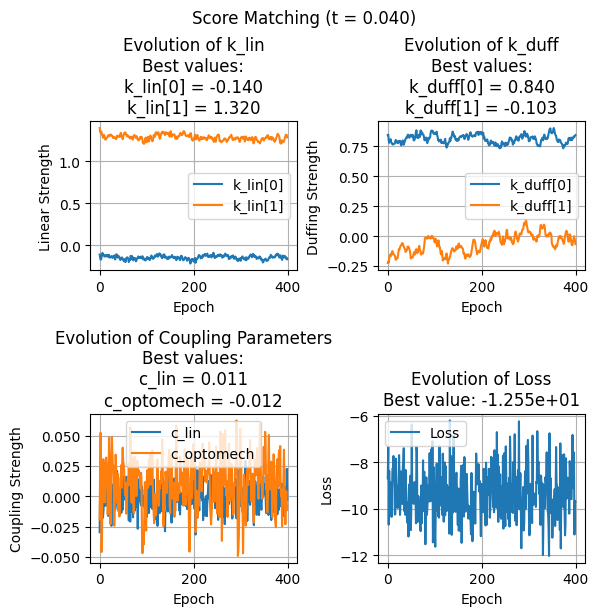

t = 0.040 probability distribution total (should be ≈ 1): 1.000000


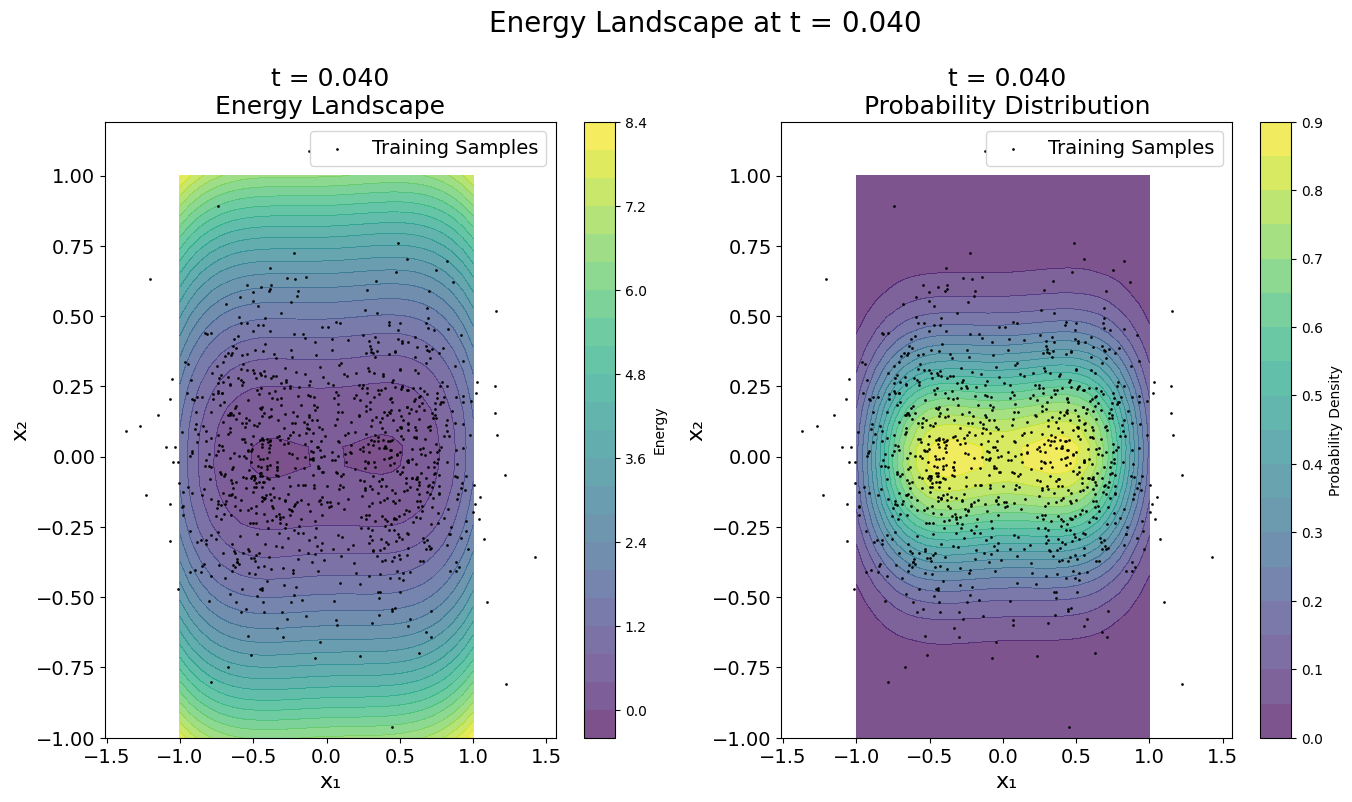

Optimizing for t = 0.042
Epoch 0
params:
[-1.49580664e-01  1.30965250e+00  8.29833188e-01 -1.12942226e-01
  1.27702733e-03 -1.84168000e-03]
Loss: -7.8394
---
Epoch 100
params:
[-0.04093829  1.06741736  0.5845022  -0.00884532 -0.01195013 -0.01951358]
Loss: -7.2336
---
Epoch 200
params:
[-0.02320714  1.06557011  0.53596132  0.12879184 -0.00617623 -0.05905518]
Loss: -6.4108
---
Epoch 300
params:
[ 0.01990944  1.01992616  0.50228428  0.21482553 -0.0042118   0.0020673 ]
Loss: -9.4940
---
Epoch 400
params:
[ 0.04951455  1.02710302  0.48476442  0.24914291 -0.01470609  0.00309331]
Loss: -5.6369
---
Epoch 500
params:
[ 0.05388793  1.03180806  0.51779562  0.25663349 -0.02032013  0.00274214]
Loss: -8.9535
---
Epoch 600
params:
[ 0.05156741  1.00360157  0.51206734  0.26999063 -0.01693003  0.01764475]
Loss: -6.1015
---
Epoch 700
params:
[ 0.02283449  0.98501515  0.48701018  0.2321002  -0.01816573  0.00650187]
Loss: -8.5894
---
Epoch 800
params:
[ 0.02061911  1.00734165  0.46335736  0.2070662  -0.00

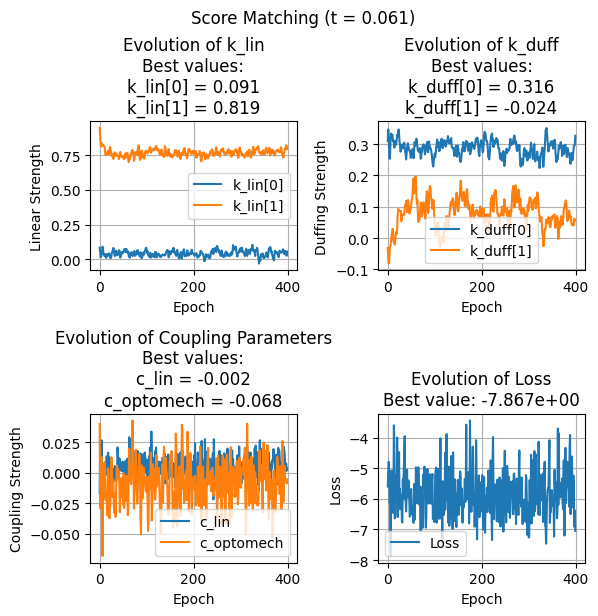

t = 0.061 probability distribution total (should be ≈ 1): 1.000000


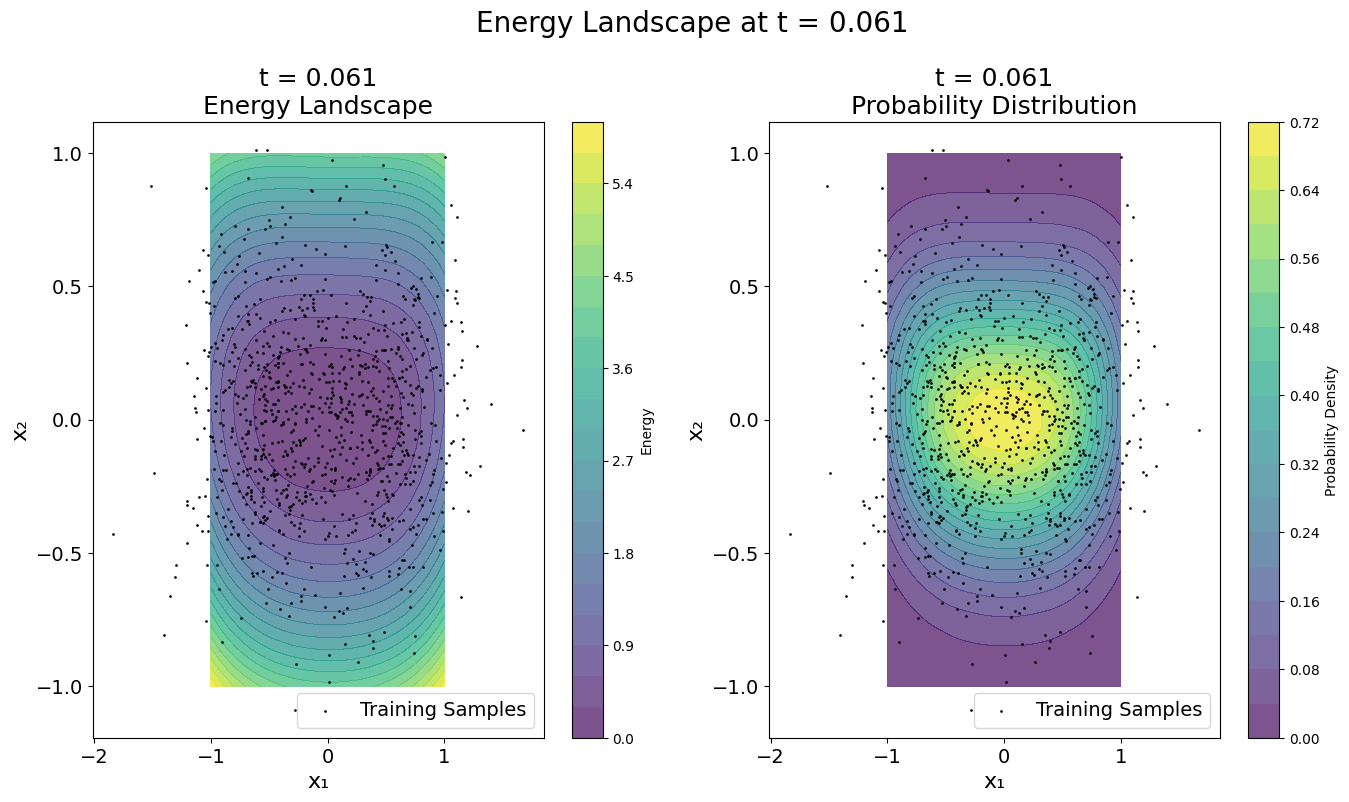

Optimizing for t = 0.063
Epoch 0
params:
[ 0.08120658  0.82892813  0.30559353 -0.01375491 -0.01229418 -0.05841935]
Loss: -6.1458
---
Epoch 100
params:
[ 0.04611288  0.82254458  0.33897521 -0.04268978 -0.01562289  0.01090794]
Loss: -5.9646
---
Epoch 200
params:
[ 3.77473186e-02  7.73856211e-01  3.03476935e-01  5.47163188e-04
 -9.81247368e-04 -9.18097209e-03]
Loss: -5.8742
---
Epoch 300
params:
[ 0.101549    0.78947548  0.32458632  0.01114504 -0.00129938  0.01621259]
Loss: -4.8829
---
Epoch 400
params:
[ 0.06333653  0.81734055  0.28252881  0.01866155 -0.0054831   0.01494977]
Loss: -5.9220
---
Epoch 500
params:
[ 0.05841392  0.7690409   0.29253349  0.05015034 -0.00106424  0.02102258]
Loss: -5.2418
---
Epoch 600
params:
[ 0.0777671   0.81073093  0.2889686  -0.00845281 -0.00551319 -0.01125036]
Loss: -6.0226
---
Epoch 700
params:
[ 0.04248942  0.79019417  0.30500629  0.01000173 -0.0097158   0.00472133]
Loss: -5.4032
---
Epoch 800
params:
[ 3.71761738e-02  8.21306251e-01  3.03492399e-01 -4.80

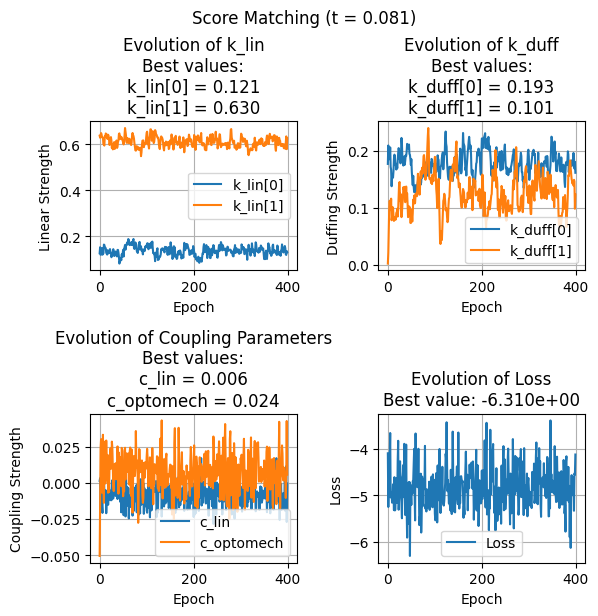

t = 0.081 probability distribution total (should be ≈ 1): 1.000000


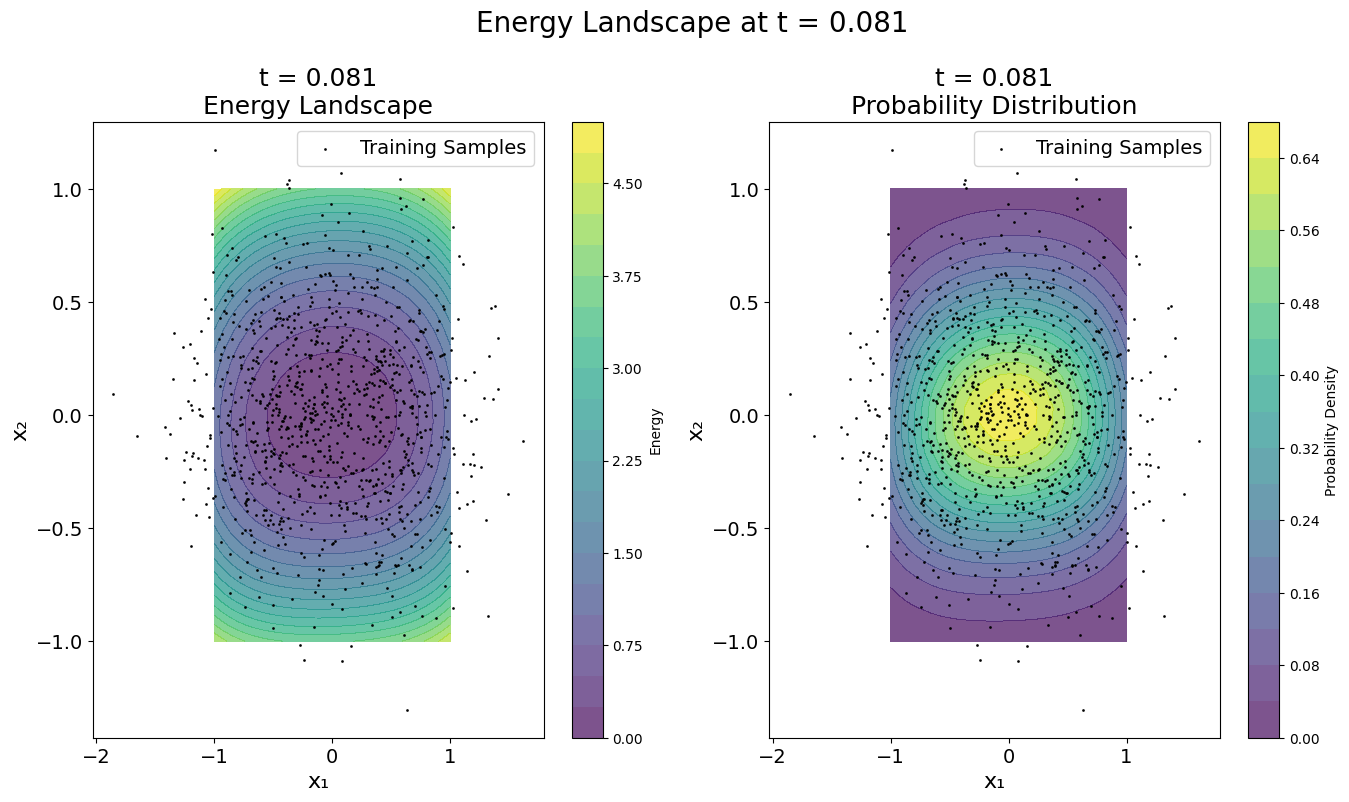

Optimizing for t = 0.083
Epoch 0
params:
[ 0.1111227   0.61951994  0.20313294  0.09086207 -0.00368442  0.0141368 ]
Loss: -4.4154
---
Epoch 100
params:
[ 0.14974751  0.60033043  0.1295439  -0.04549001 -0.00399658 -0.02905969]
Loss: -4.2841
---
Epoch 200
params:
[ 0.12028079  0.62849724  0.14003309 -0.07345572  0.00300666 -0.02148384]
Loss: -5.0601
---
Epoch 300
params:
[ 0.13190974  0.62248271  0.12805446 -0.13314773 -0.00106138 -0.00234958]
Loss: -4.2256
---
Epoch 400
params:
[ 0.14866701  0.60206821  0.13351639 -0.08759727  0.00139937 -0.00781411]
Loss: -4.0067
---
Epoch 500
params:
[ 0.15753376  0.61729303  0.15586748 -0.09638473  0.01029431 -0.03454901]
Loss: -4.9140
---
Epoch 600
params:
[ 0.16433711  0.60921548  0.11981963 -0.11061204 -0.00430015 -0.01696017]
Loss: -4.2184
---
Epoch 700
params:
[ 0.15511479  0.605806    0.09662192 -0.08615491  0.00868502  0.00259511]
Loss: -4.6972
---
Epoch 800
params:
[ 0.10906689  0.6236967   0.13553259 -0.10249512  0.00555674 -0.01810175]
Loss:

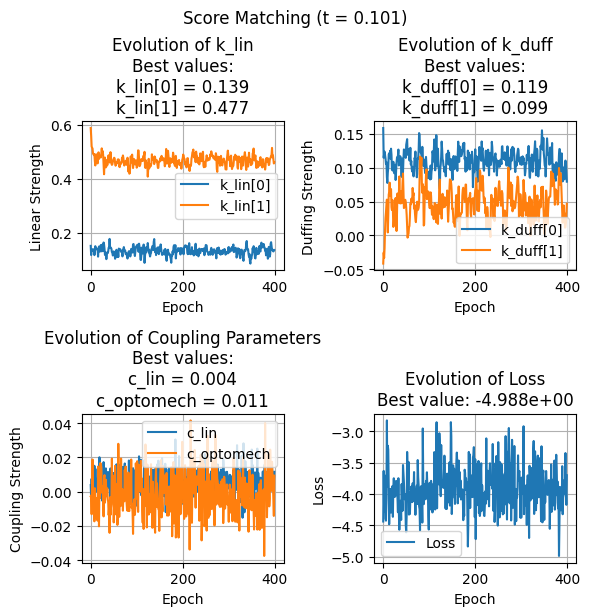

t = 0.101 probability distribution total (should be ≈ 1): 1.000000


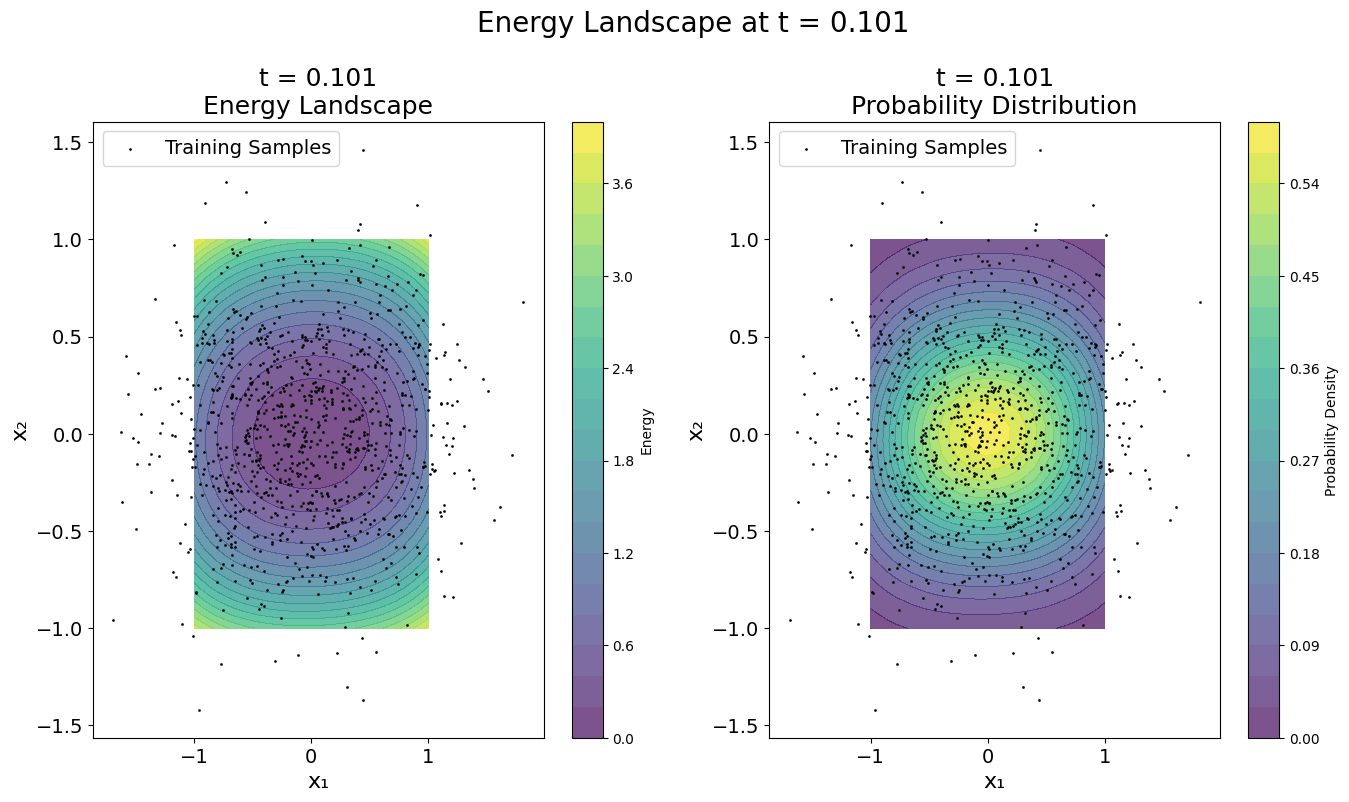

Optimizing for t = 0.103
Epoch 0
params:
[ 0.12862237  0.46722411  0.12930395  0.08948048 -0.00585451  0.02111241]
Loss: -3.8180
---
Epoch 100
params:
[ 0.15340537  0.50036761  0.08812577 -0.0222431  -0.00597165  0.00291105]
Loss: -4.1301
---
Epoch 200
params:
[ 1.30887674e-01  4.86302784e-01  1.00006246e-01 -4.47037299e-04
  8.34684019e-03 -1.70419361e-02]
Loss: -4.0504
---
Epoch 300
params:
[ 0.14298737  0.49724211  0.11444208 -0.02473819 -0.00365601  0.00727021]
Loss: -3.7912
---
Epoch 400
params:
[ 0.13061425  0.48663503  0.11902537  0.0208412  -0.00168132  0.00749093]
Loss: -3.3542
---
Epoch 500
params:
[ 0.15146748  0.47331467  0.077456   -0.02001476  0.00662902  0.00296271]
Loss: -3.7071
---
Epoch 600
params:
[ 1.98520318e-01  4.99570742e-01  1.05929893e-01 -1.52641400e-04
  5.06262960e-03  6.27155514e-03]
Loss: -3.3438
---
Epoch 700
params:
[0.15100963 0.47035646 0.09817411 0.01122647 0.02271367 0.00763778]
Loss: -4.2355
---
Epoch 800
params:
[ 0.12347879  0.50416285  0.1123905

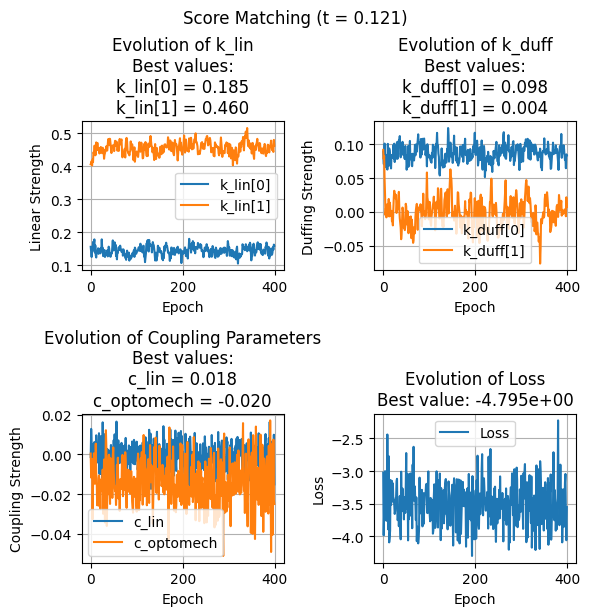

t = 0.121 probability distribution total (should be ≈ 1): 1.000000


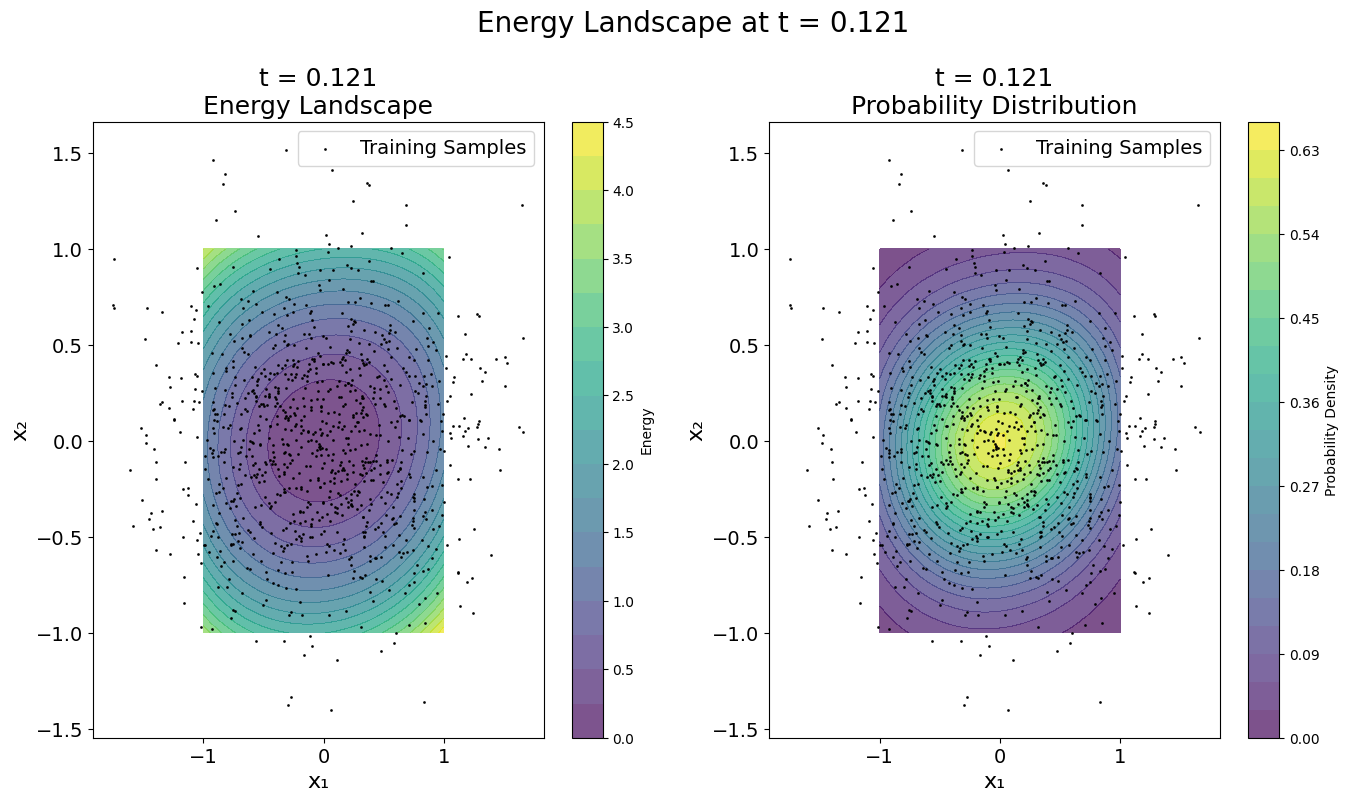

Optimizing for t = 0.123
Epoch 0
params:
[ 0.17458529  0.44960025  0.08762562  0.01435825  0.00833818 -0.01049104]
Loss: -3.3990
---
Epoch 100
params:
[ 0.1164058   0.46408558  0.10526257 -0.02571658  0.00766741  0.01731447]
Loss: -3.4322
---
Epoch 200
params:
[ 0.13197429  0.49176     0.09705547 -0.04014567  0.00427581  0.01534457]
Loss: -3.6190
---
Epoch 300
params:
[ 0.135208    0.45670369  0.10304914 -0.04150492  0.0066624   0.0154166 ]
Loss: -3.7782
---
Epoch 400
params:
[ 0.11113655  0.46526911  0.09910948 -0.01075162  0.00058541  0.02304148]
Loss: -3.7935
---
Epoch 500
params:
[ 1.10401129e-01  4.80552261e-01  8.84814987e-02 -1.45805680e-04
 -9.74516450e-04 -4.10136965e-03]
Loss: -3.5030
---
Epoch 600
params:
[ 0.13069047  0.48608354  0.11025387 -0.01776135 -0.00310991 -0.00560641]
Loss: -3.4780
---
Epoch 700
params:
[ 0.12552777  0.45813013  0.11800363 -0.02797367  0.00581459  0.00220708]
Loss: -3.6122
---
Epoch 800
params:
[1.43244795e-01 4.55199453e-01 1.07647161e-01 1.134045

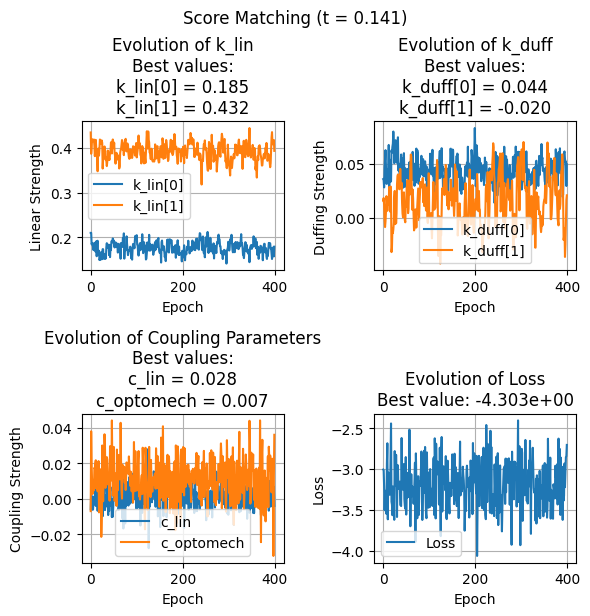

t = 0.141 probability distribution total (should be ≈ 1): 1.000000


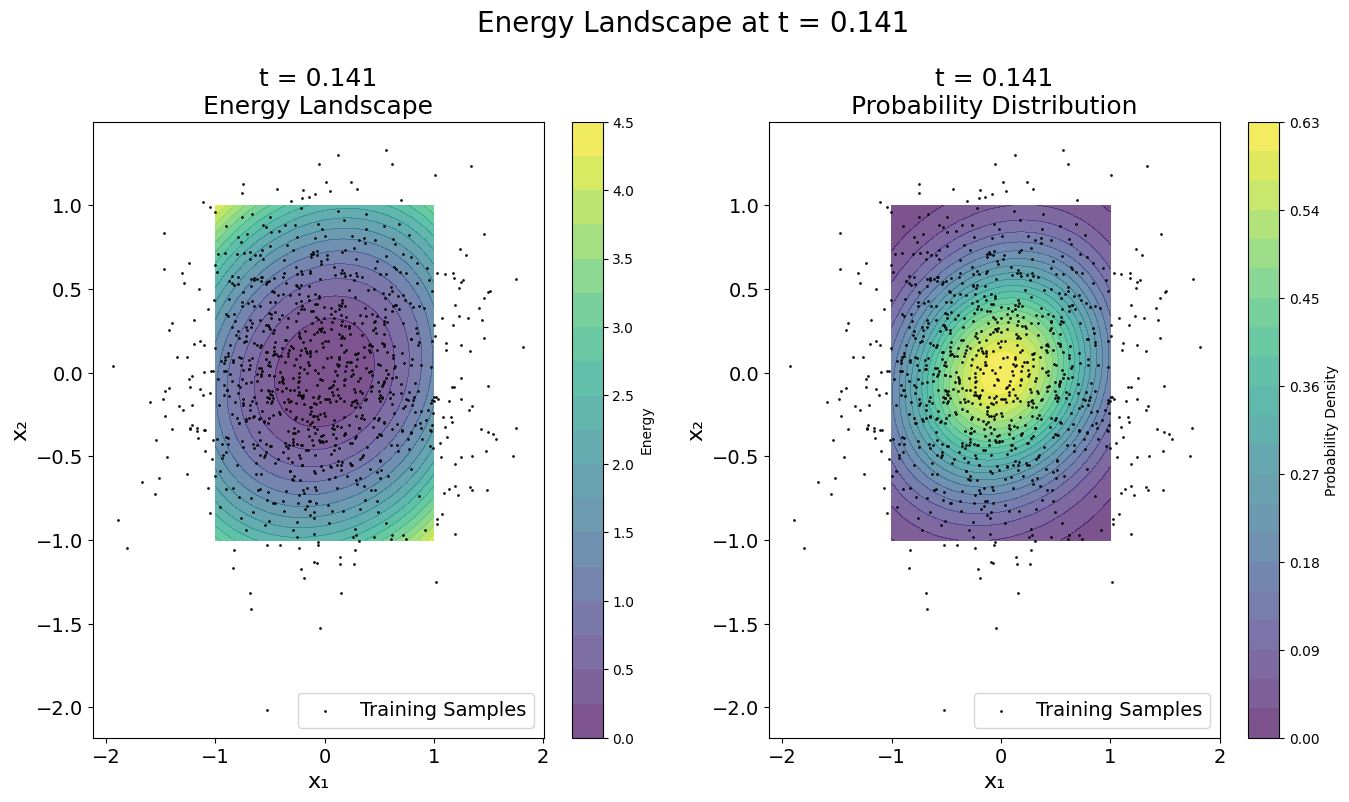

Optimizing for t = 0.143
Epoch 0
params:
[ 0.17459587  0.42209189  0.0338025  -0.02973177  0.01777283  0.0166769 ]
Loss: -2.8155
---
Epoch 100
params:
[ 0.21468175  0.31075899  0.00725677  0.11200923 -0.01270517  0.02655739]
Loss: -2.8761
---
Epoch 200
params:
[ 0.2356652   0.35164994  0.00382473  0.06621619 -0.00926227  0.01498471]
Loss: -3.3036
---
Epoch 300
params:
[ 0.22560022  0.33288473  0.03718479  0.10435349 -0.01457292  0.01395809]
Loss: -3.5760
---
Epoch 400
params:
[ 0.25590547  0.32522483 -0.00152466  0.07283474  0.01391472  0.02633789]
Loss: -3.7903
---
Epoch 500
params:
[ 0.2208057   0.32714836  0.01613505  0.09392284 -0.00111529  0.01778681]
Loss: -3.3986
---
Epoch 600
params:
[ 0.22651894  0.31746613  0.01562844  0.08211258 -0.00717701  0.02746044]
Loss: -3.5824
---
Epoch 700
params:
[ 0.24830339  0.33153101  0.01692387  0.10355365 -0.01571653  0.0171509 ]
Loss: -3.0877
---
Epoch 800
params:
[ 0.24267217  0.34165273 -0.0034531   0.085155   -0.0062776   0.02679868]
Loss:

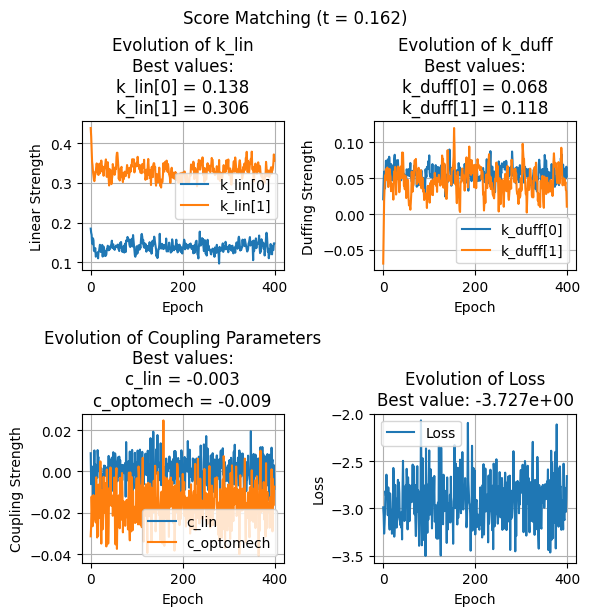

t = 0.162 probability distribution total (should be ≈ 1): 1.000000


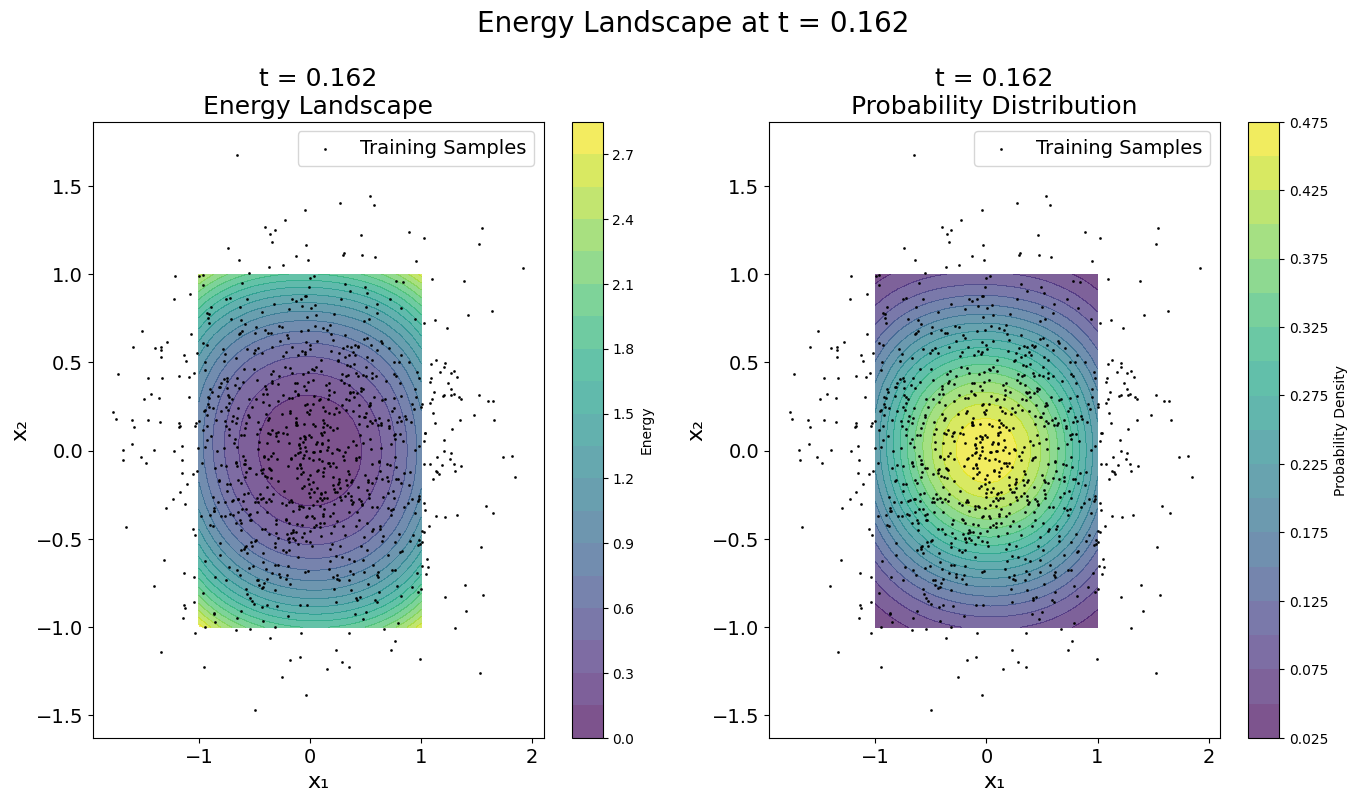

Optimizing for t = 0.164
Epoch 0
params:
[ 0.14773361  0.29598535  0.07785567  0.10798072 -0.01337753  0.00116525]
Loss: -2.9985
---
Epoch 100
params:
[ 0.24924757  0.34629169  0.01100724 -0.00516127 -0.00723594 -0.00425862]
Loss: -2.7893
---
Epoch 200
params:
[ 0.21144424  0.33253134  0.01386536 -0.00206149  0.00062381 -0.01134275]
Loss: -3.1542
---
Epoch 300
params:
[ 0.21656839  0.36561883  0.00718433 -0.0337725  -0.00652728  0.01028976]
Loss: -2.6142
---
Epoch 400
params:
[ 2.25603471e-01  3.71966878e-01 -9.28102662e-04  2.10151783e-03
  1.26169581e-04  7.10702732e-03]
Loss: -2.6521
---
Epoch 500
params:
[ 0.23360029  0.35090477  0.00187681 -0.02610681 -0.0061183  -0.00208471]
Loss: -2.9460
---
Epoch 600
params:
[ 0.22537739  0.36651058 -0.00787699  0.01473464 -0.0027016   0.00069304]
Loss: -2.9267
---
Epoch 700
params:
[ 0.23380165  0.38610617 -0.0008448   0.00140619 -0.01552348  0.00039125]
Loss: -2.8885
---
Epoch 800
params:
[ 0.23299954  0.34905585  0.00448418  0.00105687 -0.00

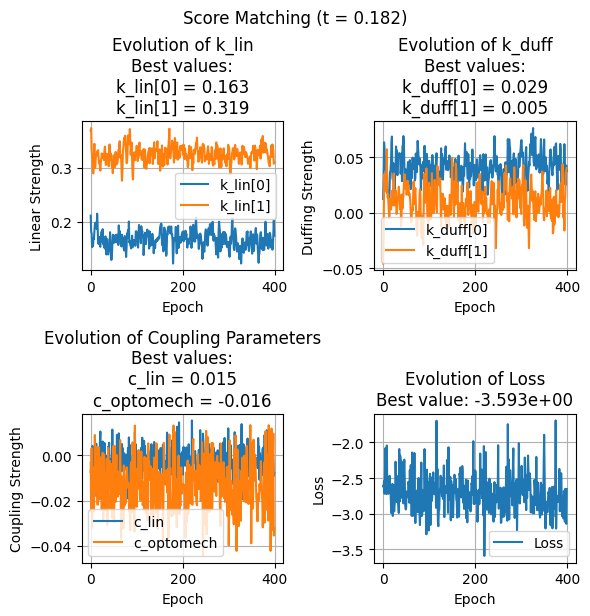

t = 0.182 probability distribution total (should be ≈ 1): 1.000000


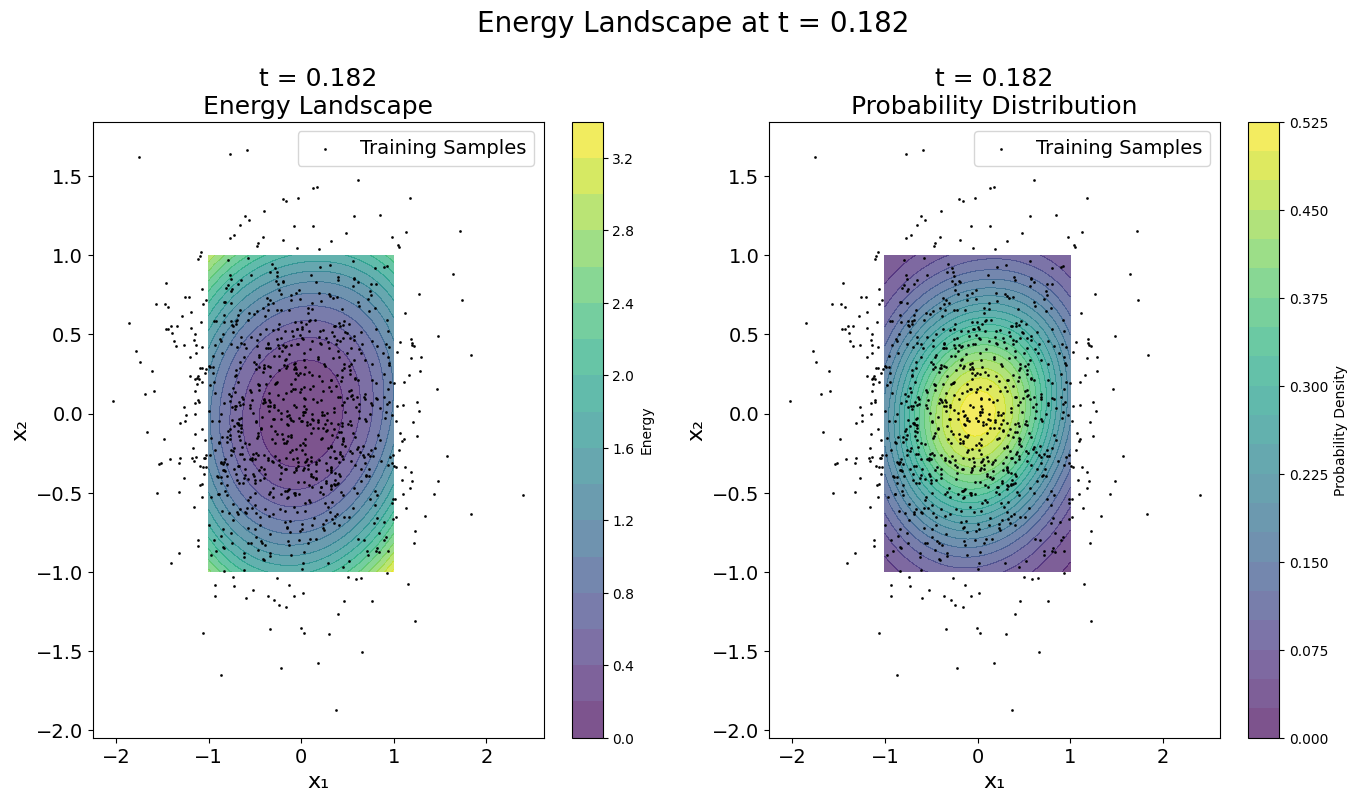

Optimizing for t = 0.184
Epoch 0
params:
[ 0.15323707  0.30871703  0.01886188 -0.00515325  0.00537051 -0.00624549]
Loss: -2.1395
---
Epoch 100
params:
[ 0.17457634  0.34027428  0.00575056 -0.00456715  0.00183942  0.01123915]
Loss: -2.5579
---
Epoch 200
params:
[ 0.16616537  0.33929395  0.01693708 -0.01584205 -0.01548751 -0.00403811]
Loss: -2.4896
---
Epoch 300
params:
[ 1.76852301e-01  3.62728232e-01  5.32210753e-03 -1.29630558e-02
 -7.28416890e-03  1.08291120e-04]
Loss: -2.5051
---
Epoch 400
params:
[ 0.16050401  0.33640478  0.00498266 -0.00793805  0.00399806  0.00380169]
Loss: -2.4489
---
Epoch 500
params:
[ 0.15172623  0.36704534  0.00989646 -0.00488587  0.00357246  0.00931134]
Loss: -2.7038
---
Epoch 600
params:
[ 0.18344098  0.34359335  0.0083899  -0.01623877  0.00629025  0.01019354]
Loss: -2.7490
---
Epoch 700
params:
[ 0.18159297  0.34093892  0.01346631 -0.01030006 -0.00436891  0.00578485]
Loss: -2.3355
---
Epoch 800
params:
[ 0.18302433  0.34194624  0.01324149 -0.00888741 -0.00

In [10]:
# Choose loss function and gradient function
loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
gradient_fn_per_batch = None
maximize = False

# Setup optimization parameters
n_time_steps = 100
forward_time_pts = jnp.linspace(0., .2, n_time_steps)
learning_rate = 0.01
n_epochs = 4000
batch_size = 128

# Plotting parameters
plot_steps = True  # Flag to control whether to plot during optimization
plot_slice = 10     # Plot every nth step


# Initialize storage for parameters at each time step
params_history_all_t = []
current_params = flattened_args_initial

# Loop over time points
for t_idx, t_forward in enumerate(forward_time_pts):
    print(f"Optimizing for t = {t_forward:.3f}")
    
    # Generate samples at current time
    key, subkey = jr.split(key)
    samples_t = sample_forward_process_minusx_plus_sqrt2D_dw(
        t_forward, n_samples, D=1, samples0=samples_0, key=subkey
    )
    
    # Perform optimization starting from previous best parameters
    key, subkey = jr.split(key)
    
    params_history, loss_history = run_optimization(
        loss_fn_per_batch=loss_fn_per_batch,
        params_initial=current_params,
        samples=samples_t,
        gradient_fn_per_batch=gradient_fn_per_batch,
        key=subkey,
        batch_size=batch_size,
        learning_rate=learning_rate,
        n_epochs=n_epochs,
        maximize=maximize
    )
    
    _, best_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
    k_lin_best, k_duff_best, c_lin_best, c_optomech_best = unflatten(best_params)
    current_params, _ = flatten_util.ravel_pytree(best_params)
    params_history_all_t.append(current_params)
    
    if plot_steps and t_idx % plot_slice == 0:
        # Plot optimization progress
        plot_parameter_evolution(
            params_history=params_history,
            loss_history=loss_history,
            unflatten=unflatten,
            N_osc=N_osc,
            slicing=10,
            title=f"Score Matching (t = {t_forward:.3f})",
            maximize=maximize
        )
        # Plot current energy landscape
        plot_energy_and_distributions(
            energy_fn=energy_fn,
            param_list=[current_params],
            samples=samples_t,
            x1_range=(-1, 1),
            x2_range=(-1, 1),
            n_points=30,
            titles=[f"t = {t_forward:.3f}"],
            fontsize=16,
            sample_stride=1,
            suptitle=f"Energy Landscape at t = {t_forward:.3f}"
        )
    
# Convert params_history_all_t to array for easier analysis
params_history_all_t = jnp.array(params_history_all_t)


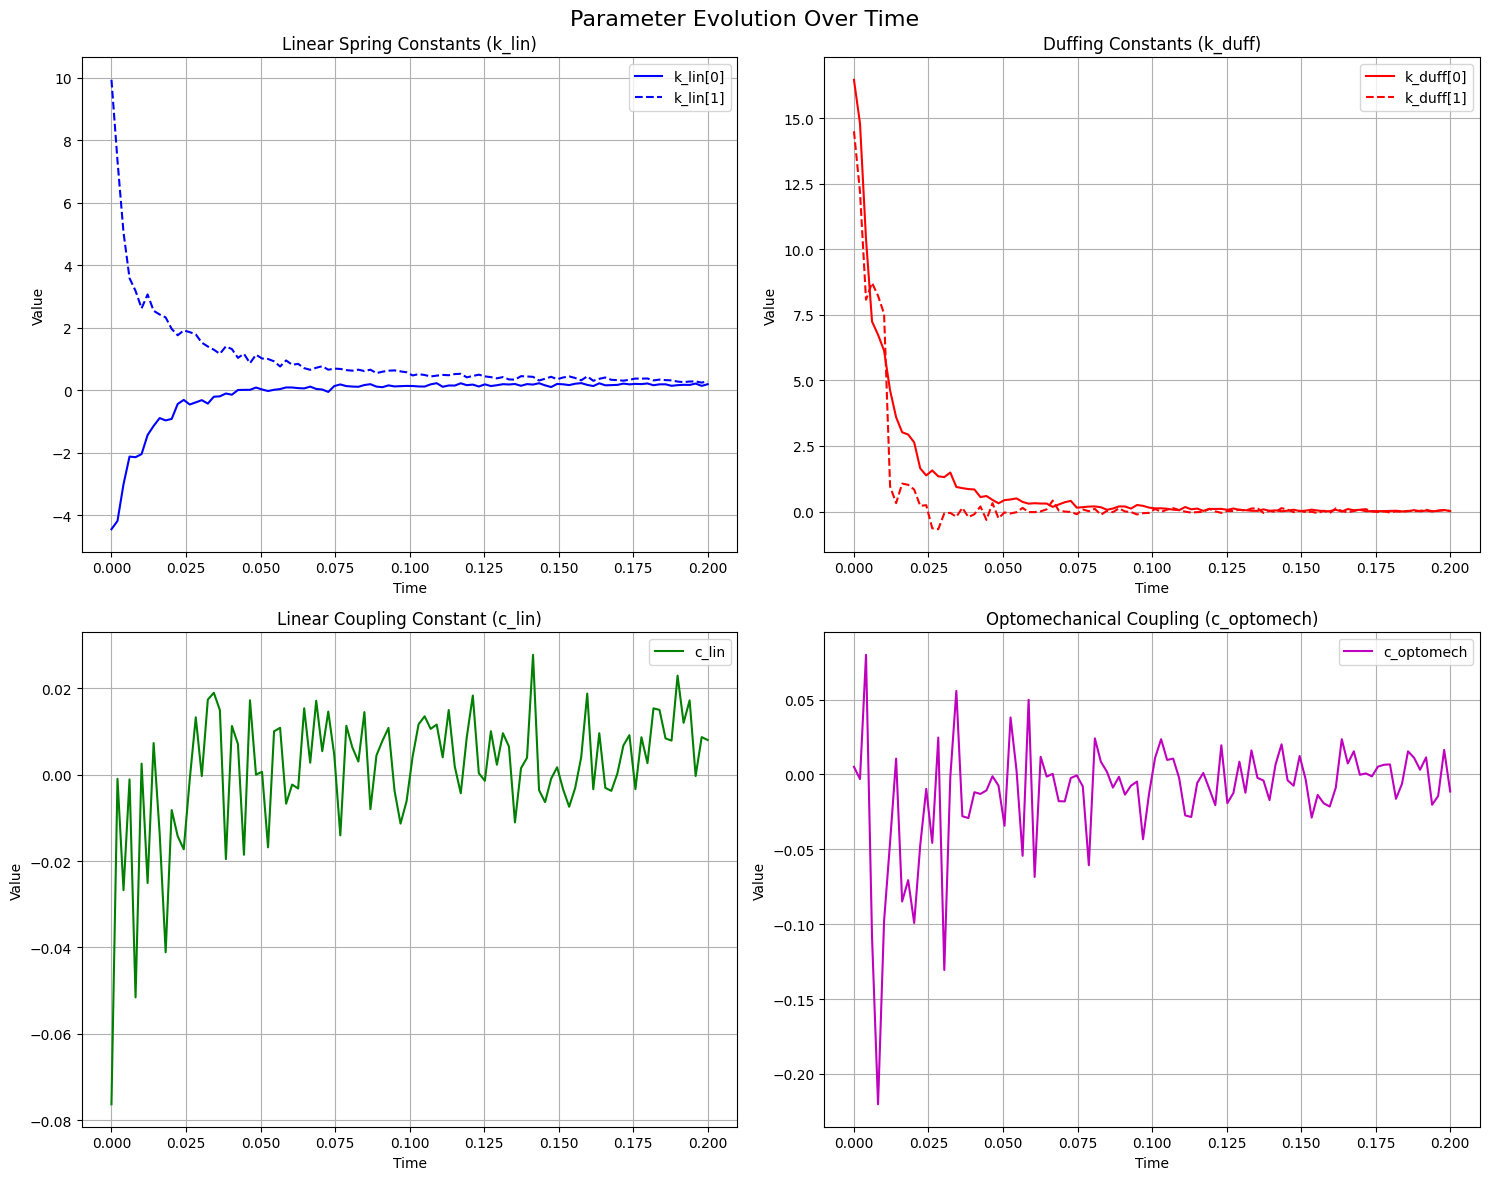

In [11]:
# Create a figure with subplots for each parameter type
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time', fontsize=16)

# Time points
time_points = forward_time_pts

# Plot k_lin parameters
ax1.plot(time_points, params_history_all_t[:, 0], 'b-', label='k_lin[0]')
ax1.plot(time_points, params_history_all_t[:, 1], 'b--', label='k_lin[1]')
ax1.set_title('Linear Spring Constants (k_lin)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Value')
ax1.legend()
ax1.grid(True)

# Plot k_duff parameters
ax2.plot(time_points, params_history_all_t[:, 2], 'r-', label='k_duff[0]')
ax2.plot(time_points, params_history_all_t[:, 3], 'r--', label='k_duff[1]')
ax2.set_title('Duffing Constants (k_duff)')
ax2.set_xlabel('Time')
ax2.set_ylabel('Value')
ax2.legend()
ax2.grid(True)

# Plot c_lin parameter
ax3.plot(time_points, params_history_all_t[:, 4], 'g-', label='c_lin')
ax3.set_title('Linear Coupling Constant (c_lin)')
ax3.set_xlabel('Time')
ax3.set_ylabel('Value')
ax3.legend()
ax3.grid(True)

# Plot c_optomech parameter
ax4.plot(time_points, params_history_all_t[:, 5], 'm-', label='c_optomech')
ax4.set_title('Optomechanical Coupling (c_optomech)')
ax4.set_xlabel('Time')
ax4.set_ylabel('Value')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

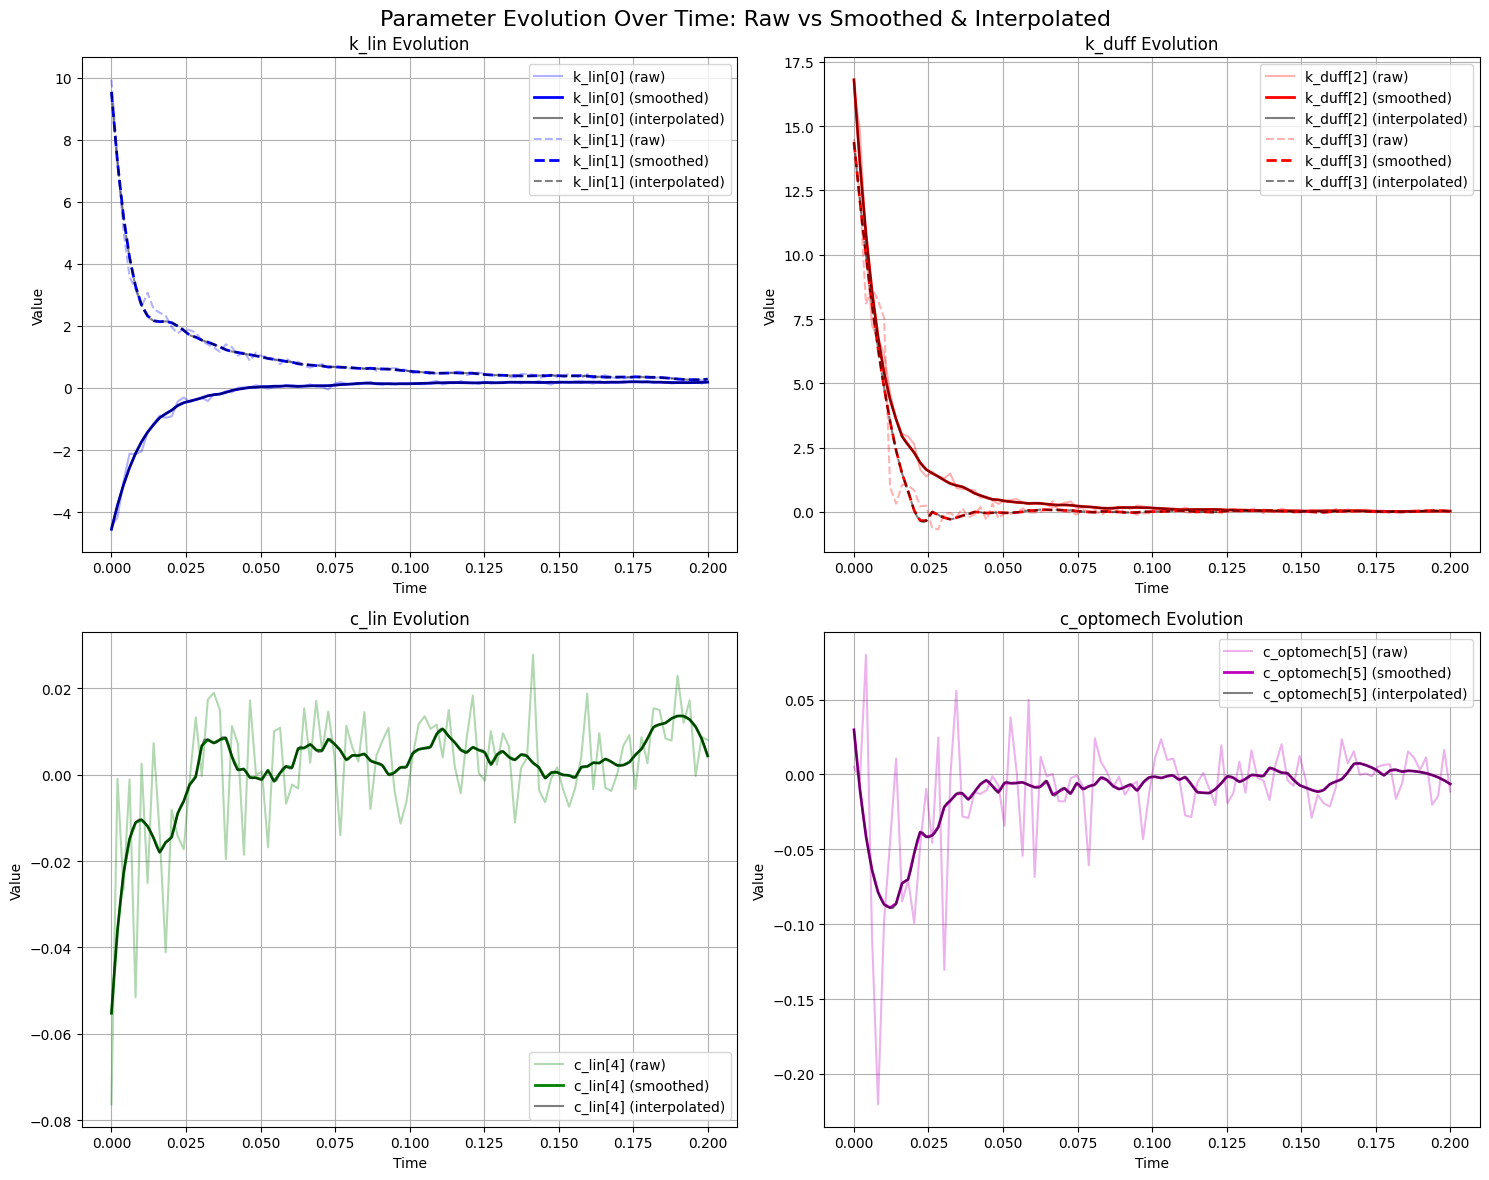

In [12]:
from scipy.signal import savgol_filter
from scipy.interpolate import CubicSpline

# Create a figure with subplots for each parameter type
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Raw vs Smoothed & Interpolated', fontsize=16)

# Time points
time_points = forward_time_pts
time_points_dense = jnp.linspace(time_points[0], time_points[-1], 200)

# Function to smooth and interpolate
def smooth_and_interpolate(data, time_points):
    # Smooth using Savitzky-Golay filter
    # Window length must be odd and less than data length
    window_length = min(15, len(data) - (1 - len(data) % 2))
    if window_length % 2 == 0:
        window_length -= 1
    smoothed = savgol_filter(data, window_length, 3)
    
    # Create cubic spline interpolator
    cs = CubicSpline(time_points, smoothed)
    return smoothed, cs(time_points_dense)

# Plot for each parameter type
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = ['b', 'r', 'g', 'm']
param_indices = [(0,1), (2,3), (4,), (5,)]

for ax, param_name, color, indices in zip(axes, param_names, colors, param_indices):
    for idx, style in zip(indices, ['-', '--']):
        raw_data = params_history_all_t[:, idx]
        smoothed, interpolated = smooth_and_interpolate(raw_data, time_points)
        
        # Plot raw data
        ax.plot(time_points, raw_data, color + style, alpha=0.3, 
                label=f'{param_name}[{idx}] (raw)')
        
        # Plot smoothed data
        ax.plot(time_points, smoothed, color + style, linewidth=2,
                label=f'{param_name}[{idx}] (smoothed)')
        
        # Plot interpolation
        ax.plot(time_points_dense, interpolated, 'k' + style, alpha=0.5, 
                label=f'{param_name}[{idx}] (interpolated)')
    
    ax.set_title(f'{param_name} Evolution')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

### Contrastive Divergence 1

In [ ]:
# Define optimization parameters
learning_rate = learning_rate
n_epochs = n_epochs
batch_size = batch_size
loss_fn_per_batch_SM = setup_score_matching_loss_per_batch(energy_fn)
key, subkey = jr.split(key)
cd1_grad = lambda params, batch: -CD1_gradient(energy_fn, 
                                               batch, 
                                               params, 
                                               dt=0.001, 
                                               D=1, 
                                               key=key, 
                                               num_noise_samples=100)

params_history_cd1, loss_history_cd1 = run_optimization(loss_fn_per_batch = loss_fn_per_batch_SM, 
                                                        params_initial = flattened_args_initial, 
                                                        samples=samples, 
                                                        gradient_fn_per_batch = cd1_grad, 
                                                        key=subkey,
                                                        batch_size=batch_size, 
                                                        learning_rate=learning_rate, 
                                                        n_epochs=n_epochs)

In [ ]:
k_lin_best_cd1, k_duff_best_cd1, c_lin_best_cd1, c_optomech_best_cd1 = plot_parameter_evolution(
    params_history=params_history_cd1,
    loss_history=loss_history_cd1,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=10,
    title="CD1"
)
args_best_cd1 = (k_lin_best_cd1, k_duff_best_cd1, c_lin_best_cd1, c_optomech_best_cd1)
flattened_args_best_cd1, _ = flatten_util.ravel_pytree(args_best_cd1)


### MLE

In [ ]:
# Define optimization parameters
learning_rate = .5
n_epochs = 100
batch_size = samples.shape[0]//2
key, subkey = jr.split(key)
loss_fn_per_batch_MLE = setup_MLE_loss_per_batch(energy_fn)
gradient_fn_per_batch_MLE = setup_MLE_gradient_per_batch(energy_fn, 
                                                     N_osc, 
                                                     gamma=1.0, 
                                                     k_b=1.0, 
                                                     T=1.0, 
                                                     t0=0.0, 
                                                     t1=10.0, 
                                                     N_samples=1000, 
                                                     dt0=0.01, 
                                                     initial_state=jnp.array([0.,0.]))

params_history_mle, loss_history_mle = run_optimization(loss_fn_per_batch = loss_fn_per_batch_MLE, 
                                                        params_initial = flattened_args_initial, 
                                                        samples=samples,
                                                        gradient_fn_per_batch = gradient_fn_per_batch_MLE, 
                                                        key=key,
                                                        batch_size=batch_size, 
                                                        learning_rate=learning_rate, 
                                                        n_epochs=n_epochs, 
                                                        maximize=True)

In [ ]:
k_lin_best_mle, k_duff_best_mle, c_lin_best_mle, c_optomech_best_mle = plot_parameter_evolution(
    params_history=params_history_mle,
    loss_history=loss_history_mle,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=1,
    title="MLE",
    maximize=True
)
args_best_mle = (k_lin_best_mle, k_duff_best_mle, c_lin_best_mle, c_optomech_best_mle)
flattened_args_best_mle, _ = flatten_util.ravel_pytree(args_best_mle)

### Compare solutions

In [ ]:
# Example usage:
param_list = [flattened_args_initial, flattened_args_best_sm, flattened_args_best_cd1, flattened_args_best_mle]
titles = ["Initial Parameters", "Score Matching Best", "CD-1 Best", "MLE Best"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples,
    x1_range=(-1, 1),    
    x2_range=(-1, 1),    
    n_points=30,        
    titles=titles,       
    figsize=None,    
    fontsize=16,
    sample_stride=1,
    suptitle="Comparison of Different Parameter Sets"  
)

### Run the SDE on one of the optimized energy landscape

In [25]:
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, flattened_args_best_sm, N_osc)
t0 = 0.0
t1 = 10 
ts = jnp.linspace(t0, t1, 10000)
dt0 = ts[1] - ts[0]
initial_state    = jnp.array([0.,0.])

solution = solve_SDE(drift_fn, diffusion_fn, initial_state, t0, t1, ts.shape[0], dt0)
sde_samples = solution.ys

In [ ]:
# Example usage:
param_list = [flattened_args_best_sm]
titles = ["Score Matching Best Energy "]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples,
    sample_stride=1,
    x1_range=(-1, 1),    # optional
    x2_range=(-1, 1),    # optional
    n_points=30,        # optional
    titles=titles,       # optional
    figsize=None,    # optional
    fontsize=12,         # optional
    suptitle="Energy landscape with SDE samples"  # optional
)